<a href="https://colab.research.google.com/github/woodRock/deep-learning-goodfellow/blob/main/chapter_8_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How Learning Differs from Pure Optimization

Optimization algorithms used for training deep models differ from traditional optimization algorithms in several way. Machine learning usually acts indirectly. In most machine learning scenarios, we care about some performance measure $P$, that is defined with respect to the test set and may also be intractable. We reduce a different cost function $J(\theta)$ in the hope that doing so will improve $P$.

Typically, the cost function can be written as an average over the training set, such as

$$ J(\theta) = \mathbb{E}_{(x,y)~\hat{p}_{data}} L (f(x;\theta), y)$$

where $L$ is the per-example loss function, $f(x;\theta)$ is the predicted  output in when the input ix $x$ and $\hat{p}_{data}$.

## Empirical Risk Minimization

The goal of a machine learning algorithm is to reduce the expected generalization error given by the equation above. This quantity is known as the **risk**.

The simplest way to convert a machine learning problem back into an optimization problem is to minimize the exptected loss on the training set. This means replacing the true distribution $p(x,y)$ with the empircal distribution $\hat{p}(x,y)$ defined by the training set. We now minimize the **empirical risk**

$$ \mathbb{E}_{(x,y)}[l(f(x;\theta),y)] = \frac{1}{m} \sum^m_{i=1} L (f(x^{(i)};\theta), y^{(i)})$$

Problems:
1. Empirical risk is prone to overfitting. Models with high capacity can simply memorize the training set.
2. Many useful loss functions, such as 0-1 loss, have no useful derivatives (the derivative is either zero  or undefined everywhere).

These two problems mean we rarely use empirical risk minimization. Instea, we use a slightly different approach, in which the quantity we actually optimize is even more different from the quantity that we truly want to optimize.

## Surrogate Loss Functions and Early Stopping

Sometimes, the loss function we actually care about is not one that can be opimized efficiently. For example, exactly minimizing expected 0-1 loss is typically intractable (exponential in the input dimension), even for a linear classifier. In such situations, one typically optimizes a **surrogate loss function** instead, which acts as a proxy but has advantages.

For example, the negative log-likelihood of the correct class is typically used as a surrogate for 0-1 loss. The negative log-likelihood allows the model to estimate the condititional probability of the classes, given the input, and if the model can do that well, then it can pick the classes that yield the least classification error in expectation.

## Batch and Minibatch Algorithms

One aspect of machine learning algorithms that seperates them from general optimization algorithms is that the objective function usually decomposes as a sum over the training examples.

For example, maxmimum likelihood estimation problems, when viewed in log space, decompose into a sum over each example.

$$ \theta_{ML} = argmax_{\theta} \sum^m_{i=1} p_{model}(x^{(i)}, y^{(i)}; \theta) $$

Maximizing this sum is equivalent to maximizing the expectation over the empircal distribution defined by the training set:

$$ J(\theta) = \mathbb{E}_{x,y}~\hat{p}_{data} \log p_{model}(x,y;\theta) $$

Most of the properties of the objective function $J$ used by most of our optimization algorithms are also expectations over the training set. For example the most commonly used property is the gradient:

$$ \nabla_{\theta}J(\theta) = \mathbb{E}_{x,y~\hat{p}_{data}} \nabla_{\theta} \log p_{model} (x;y;\theta)$$

## Stream of data

The fact that stochastic gradient descent minimizes generalization error is easiet seen in online learning, where examples or minibatches are drawn from a **stream** of data. In other words, instead of receiving a fixed-size training set, the learneer is similar to a livigin being who sees a new example each instant, with every example $(x,y)$ coming from the data-generating distribution $p_{data}(x,y)$. In this scenario, examples are never repeated; every experience is a fair sample from $p_{data}$.

The equivalence is easier to dervice when both $x$ and $y$ are discrete. In this case, the generalization error can be written as a sum

$$ J^* (\theta) = \sum_x \sum_y p_{data}(x,y) L(f(x;\theta),y) $$

with the exact gradient:

$$ g = \nabla_{\theta} J^* (\theta) = \sum_x \sum_y p_{data}(x,y) \nabla_{\theta} L(f(x;\theta),y) $$

Hence, we obtain an unbiased estimator of the exact gradient of the generalization error by sampling a minibatch of examples $ \{x^{(1)}, \cdots, x^{(m)} \} $ with corresponding targets $y^{(i)}$ from the data-generating distribution $p_{data}$, the computing the gradient of the loss with respect to the parameters for that minibatch.

$$ \hat{g} = \frac{1}{m} \nabla_{\theta} \sum_i L(f(x^{(i)};\theta),y^{(i)})$$

Updating $\theta$ in the direction $\hat{g}$ performs SGD on the generalization error.

Note: this interpretation applies only when examples are not reused.

# Challenges in Neural Network Optimization

Optimization in general is an extremely difficult task. Traditionally, machine learning has avoided the difficulty of general optimization by carefully designing the objective function and constraints to ensure that the optimization problem is convex. When training neural networks, we must confront the general nonconvex case. Even convex optimization is not without its complications.

## Ill-conditioning

Some challenges arise even when optimizing convex functions. OF these, the most promininent is ill-conditionding of the Hessian matrix $H$. This is a very general problem in most numerical optimization, convex or otherwise, described in more detail [here](https://github.com/woodRock/deep-learning-goodfellow/blob/main/chapter_4_numerical_computation.ipynb).

The ill-conditioning problem is generally believed to be present in neural network training problems. Ill-conditioning can manifest by causing SGD to get "stuck" in the sense that even very small steps increase the cost function.

That second-order Taylor series expansion of the cost function predicts that a gradient descent step of $\epislon g$ will add:

$$ \frac{1}{2} \epsilon^2 g^{\top} Hg - \epsilon g^{\top} g $$

to the cost. Ill-conditioning becomes a problem when $\frac{1}{2} \epsilon^2 g^{\top} Hg$ exceeds $\epsilon g^{\top} g$. To determine whether ill-conditioning is detrimental to a neural network training task, one can monitor the squared gradient norm $g^{\top}g$ and the $g^{\top} Hg$ term. In many cases, the gradient norm does not shrink signficantly throughout learning, but the $g^{\top} Hg$ grows by more than an order of magnitude.

## Local Minima

One of the most prominent features of a convex optimization problem is that it can be reduced to the problem of finding a local minimum. Any local minimum is guaranteed to be a global minimum. Some convex functions have a flat region at the bottom rather than a single global minimum points, but any point within such a flat region is an acceptable solution.

With nonconvex functions, such as neural nets, it is possible to have many local minima. Indead nearly any deep model is essentially guaranteed to have an extremely large number of local minima.

Neural networks and any models with mutliple euqivalently parameterized latent variables all have multiple local minima because of the **model identifiability** problem. A model is said to be identifiable if a sufficiently large training set can rule out all but one setting of the model's parameters. Models with latent variables are often not identfiable  because we can obtrain equivalent models by exchanging latent variables with each other. For example we could take a neural network and modify layer 1 by swapping the incoming weight vector for unit $i$ with the incoming weight vector for unit $j$, then do the same for the outgoing weight vectors. If we have $m$ layers with $n$ units each, then there are $n!^m$ ways if arranging the hidden units. This kind of nonidentifiability is known as **weight space symmetry**.

"So, neural networks are super cool, but they’re tricky because they have lots of ways to be “just as good,” like building the same awesome tower with different block arrangements!" - Grok


## Plateaus, Saddle Points and Other Flat Regions

For many high-dimensional nonconvex functions, local minima (and maxima) are in fact rare comapraed to another kind of point with zero gradient: a saddle point. Some points around a saddle point have greater cost than the saddle point, while others have a lower cost. At a saddle point, the Hessian matrix has both positive and negative eigenvalues. Points lying along eigenvectors associcated with positive eigenvalues have greather cost than the saddle point, while points lying along negative eigenvalues have lower value.We can think of a saddle point as being a local minimum along one cross-section of the cost function and a local maximum along naother corss-section.

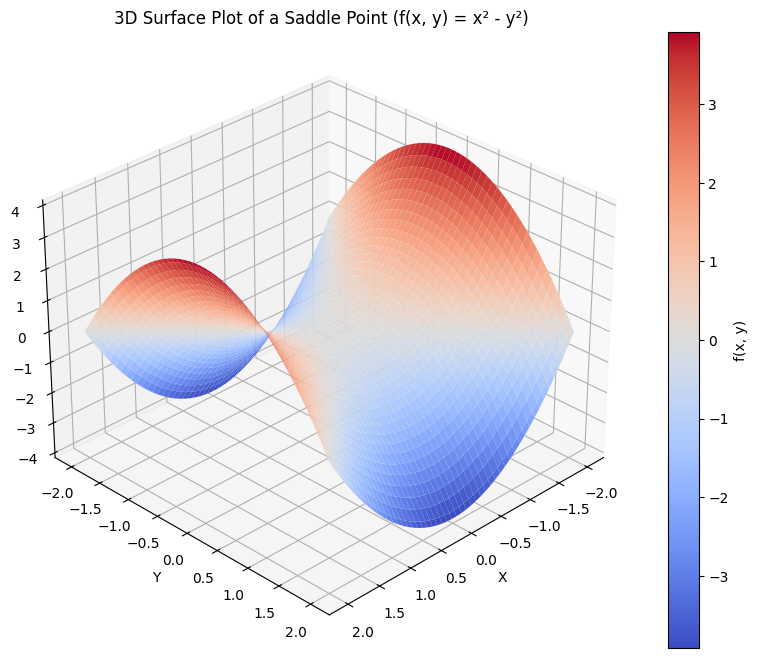

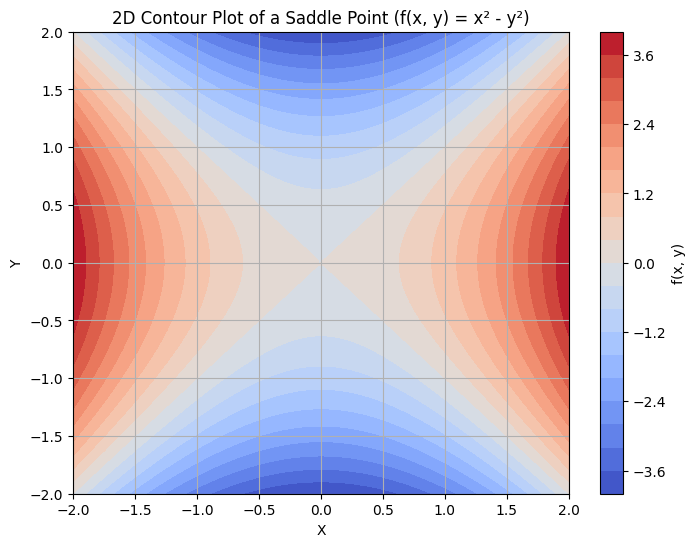

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Create a grid of x and y values
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Step 2: Define the function with a saddle point: f(x, y) = x^2 - y^2
Z = X**2 - Y**2

# Step 3: Create a 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')
fig.colorbar(surf, label='f(x, y)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('3D Surface Plot of a Saddle Point (f(x, y) = x² - y²)')
ax.view_init(elev=30, azim=45)  # Adjust viewing angle for clarity
plt.show()

# Step 4: Create a 2D contour plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=20, cmap='coolwarm')
plt.colorbar(contour, label='f(x, y)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Contour Plot of a Saddle Point (f(x, y) = x² - y²)')
plt.grid(True)
plt.show()

For Newton's method, saddle points clearly constitute a problem. Gradient descent id designed to move "downhill" and is not explicitly desgiend to seek a critical point. Newton's method , however, is designed to solve for a point where the gradient is zero. Without appropriate modification, it can jump to a saddle point.

There are other kinds of points with zero gradient besides minima and saddle points. Maxima are much like saddle points from the perspective of optimization - many algorithms are not attracted to them, but unmodified Newton's method is. Maxima of many classes of random function become exponentially rare in high-dimensional space, just as minima do.  

There may also be wide, flat regions of constant value. In these locations the gradient and the Hessian are all zero. Such degenerate locations pose major problems for all numerical optimization algorithms. In a convex problem, a wide flat region must consist entirely of global minima, but in general optimization problem, such a region could correspond to a high value of the objective function.

## Cliffs and Exploiding Gradients

Neural networks with many layers often have extremely steep regions resembling cliffs. These result from the multiplication of several large weights together. On the face of an extremely steep cliff structure, the gradient update step can move the parameters extremely far, usually jumping off the cliff structure altogether.

The cliff can be dangerous whether we approach it from above or from below, but fortunately its most serious conseqeunces can be avoided using **gradient clipping**/ The basic ideas is to recall that the gradient specifies not the optimal step size, but only the optimal direction within an infinitesimal region. When the traditiondal gradient descent algorithm proposes making a very large step, the gradeitn clipping heuristic intervenes to reduce the step size, making it less likely to go outisde the region where the gradient indicates the direction of approximately steepest desdent.

Cliff structures are most common in the cost function for recurrent neural networks, because such models involve multiplication of many factors, with one factor for each time stemp. Long temporal sequences thus incur an extreme amount of multiplication.

## Long-Term Dependencies

Another difficutly that neural network optimization algorithms must overcome arises when the computational graph becomes extremely deep. Feedforward networks with many layers such have such deep computation graphs. So do recurrent networks, which construct a very deep computational graphs by repeatedly applying the same operation at each time step of a long temporal sequence. Repeased application of the same parameters gives rise to especially pronounded difficulties.

For example, suppose that a computational graph contains a path that consists of repeatedly multipling by a matrix $W$. After $t$ steps, this is equivalent to multipling by $W^t$/ Suppose that $W$ has an eigendecomposition $W = V diag (\lambda) V ^ {-1} $. In this simple case, it is straightforward to see that

$$ W^t = (V diag (\lambda) V^{-1})^t = V diag (\lambda)^tV^{-1} $$

Any eigenvalues $\lambda_i$ that are not near an absolute value of 1 will either explode if they are greater than 1 in magnitude, or vanish if they are less than 1 in magnitude.

The **vanishing and exploding gradient problem** refers to the fact that the gradients through a deep computational graphs are also scaled according to $diag(\lambda)^{\top}$. Vanishing gradients make it difficult to know which direction the parameters should move to improve the cost function, while exploding gradients can make the learning unstable. The cliff structures described earlier that motivate gradient clipping are an example of the exploding gradient phenomenon.

## Inexact Gradients

Most optimization algorithms are designed with the assumption that we have access to teh exact gradient or Hessian matrix. In practise, we usually have a noisy or even biased estimated of these quantities. Nearly every deep learning algorithm relies on sampling-based estimates, at least insofar as using a minibatch of training examples to compute the gradient.

When the objective function is intractable, typically the gradient is intractable as well. In such cases we can only approximate the gradient. These isues mostly arise with more advanced models. For example contrastive divergence gives a technique for approximating the gradient of the intractable log-likelihood of a Boltzmann machine.

## Poor Correspondance between Local and Global Structure

Many of the problems we have dicussed so far correspond to properties of the loss function at a single point - it can be difficult to make a single step if $J(\theta)$ is poorly conditioned at the current point $\theta$m or if $\theta$ lies on a cliff, of if $\theta$ is a saddle point hiding the opportunity to make progress downhill from the gradient.

It is possible to overcome all these problems at a single point and still perform poorly if the direction that results in most improvement locally does not point toward distant regions of much lower cost.

Much of the runtime of training is due to the length of the trajectory needed to arrive at the solution.

Much of research into difficulties of optimization has focused on whether training arrives at a global minimum, a local minimum, or a saddle point, but in practise, neural networks do not arrive at a criticial point of any kind. Indeed, such critical points do not even necesarrily exist.

## Theoretical Limits of Optimization

Severak theoretical results show that there are limits on the performance of any optimization algorithm we might design for neural networks. Typically these results have little bearing on the use of neural networks in practise.

# Basic Algorithms

We have previously introduced gradient descent, see [here](https://github.com/woodRock/deep-learning-goodfellow/blob/main/chapter_4_numerical_computation.ipynb), algorithm that follows the gradient of the entire training set downhill. This may be accelerated considerably by using stochastic gradient descent to follow the gradient of randomly selected minibatches downhill.

## Stochastic Gradient Descent

Stochastic gradeint descent (SGD) and its variants are probably the most used optimization algorithms for machine learning in general and for deep learning in particular. It is possible to obtain an unbiased estimate of the gradeint by taking the average gradient on a minibatch of $m$ examples drawn i.i.d. from the data-generating distribution.

A crucial parameter for the SGD algorithm is the learning rate. Previously we have described SGD as using a fixed learning rate $\epsilon$. In practise, it is necessary to gradually deceased the learning rate over time, so we now denote the learning rate at iteration $k$ as $\epsilon_k$.

This is because the SGD estimator introduces a source of noise (the random sampling of $m$ training examples) that does not vanish even when we arrive at a minimum. By comparison, the trude gradient of the total cost function becomes small and then 0 when we approach and reach a minimum using batch gradient descent, so batch gradient descent can use a fixed learning rate.

In practise it is common to decay the learning rate linearly until iteration $\tau$:

$$ \epsilon_k = (1 - \alpha) \epsilon_0 + \alpha \epsilon_{\tau} $$


In [ ]:
class SGD(object):
    def __init__(self, parameters, alpha=0.1, total_steps=1000):
        self.parameters = parameters
        self.base_alpha = alpha
        self.current_alpha = alpha
        self.total_steps = total_steps
        self.current_step = 0

    def zero(self):
        for p in self.parameters:
            if p.grad is not None:
                p.grad.data *= 0

    def step(self, zero=True):
        # Linear learning rate decay: lr = base_lr * (1 - current_step/total_steps)
        self.current_alpha = self.base_alpha * (1.0 - self.current_step / self.total_steps)
        self.current_step += 1

        for p in self.parameters:
            if p.grad is None:
                print(f"Gradient is None for {p}")
                continue
            # Update parameters using the current learning rate
            p.data -= p.grad.data * self.current_alpha
            if zero:
                p.grad.data *= 0

    def get_lr(self):
        return self.current_alpha

To study the convergence rate of an optimization algorithm it is common to measure the **excess error** $J(\theta) - min_{\theta} J(\theta)$, which is the amount by which the current cost function exceeds the minimum possible cost. When SGD is applied to a convex problem, the excess error is $O(\frac{1}{\sqrt{k}})$ after $k$ iterations, while in the strongly convex case, it is $O(\frac{1}{k})$. These bounds cannot be improved unless extra conditions are assumed.

It may not be worthwhile to pursue an optimization algorithm that converges faster than $O(\frac{1}{k})$ for machine learning tasks - faster convergence presumably corresponds to overfitting.

## Momentum

While stochastic descent remains a popular optimization stratefy, learning with it can be slow. The method of momentum (Polyak 1964) is designed to accelerate learning, especially in the face of high curvature, small but consistent gradients, or noisy gradients. The momentum algorithm accumulates an exponetially decaying moving average of past gradients and continues to move in their direction.

Momentum aims primarily to solve two problems: poor conditioning of the Hessian matrix and variance in the stochastic gradient.

We can view the momentum algorithm as simulating a particle subject to a continious-time Newtonian dynamics.

The position of the particle at any point in time is given by $\theta(t)$. The particle experiences net force $f(t)$. This force causes the particle to accelerate:

$$ f(t) = \frac{\partial^2}{\partial t^2} \theta(t) $$

Rather than viewing this as a second-order differential equation of the position, we can introduce the variable $v(t)$ representing the velocity of the particle at time $t$ and rewrite the Newtonian dynamics as a first-order differential equation:

$$ v(t) = \frac{\partial^2}{\partial t} \theta(t) $$
$$ f(t) = \frac{\partial}{\partial t} v(t) $$

The momenum algorithm then consists of solving the differential euqations via numerical simulation. A simple numerical method for solving differential equations is Euler's method, which consists of simulating the dynamics defined by the equation by taking small, finite steps in the direction of each gradient.

In [11]:
import numpy as np

class Momentum(object):
    def __init__(self, parameters, alpha=0.9, epsilon=1e-3):
        self.parameters = list(parameters)
        self.alpha = alpha
        self.epsilon = epsilon
        # Initialize velocity as a list of zeros for each parameter
        self.velocities = [np.zeros_like(p.data) for p in self.parameters]

    def zero(self):
        for p in self.parameters:
            if p.grad is not None:
                p.grad.data *= 0

    def step(self, zero=True):
        for p, v in zip(self.parameters, self.velocities):
            if p.grad is None:
                print(f"Gradient is None for {p}")
                continue

            # Update velocity for each parameter
            v = v * self.alpha - self.epsilon * p.grad.data
            p.data += v
            if zero:
                self.zero()

# Nesterov Momentum

Sutskever introduced a variant of the momentum algorithm that was inspired by Nestero'vs accelerated gradient method (Nesterov 1983, 2004). The update rules in this case are given by

$$v \leftarrow \alpha v - \epsilon \nabla_{\theta} [\frac{1}{m} \sum^m_{i=1} L (f(x^{(i)};\theta + \alpha v), y^{(i)})]$$
$$  \theta \leftarrow \theta + v $$

The different between Nesterov momentum and standard momentum is where the gradient is evaluated. With Nesterov momentum, the gradeint is evaluated after the current velocity is applied. Thus one can interpret Nesterov momementum as attempting to add a _correction factor_ to the standard method of momentum.

In [19]:
import numpy as np
import copy

class Nesterov(object):
    def __init__(self, parameters, alpha=0.9, epsilon=1e-3):
        self.parameters = list(parameters)
        self.alpha = alpha
        self.epsilon = epsilon
        # Initialize velocity as a list of zeros for each parameter
        self.velocities = [np.zeros_like(p.data) for p in self.parameters]

    def zero(self):
        for p in self.parameters:
            if p.grad is not None:
                p.grad.data *= 0

    def step(self, zero=True):
        # Store original parameters to restore after computing look-ahead gradients
        original_params = [copy.deepcopy(p.data) for p in self.parameters]

        # Move parameters to look-ahead position: p + alpha * v
        for p, v in zip(self.parameters, self.velocities):
            p.data += v * self.alpha

        # Assume gradients are computed at the look-ahead position
        # (Caller must ensure p.grad is updated after this point)
        # Update velocities and parameters using the look-ahead gradients
        for p, v in zip(self.parameters, self.velocities):
            if p.grad is None:
                print(f"Gradient is None for {p}")
                continue

            # Update velocity: v = alpha * v - epsilon * grad(p + alpha * v)
            v = (v * self.alpha) - (p.grad.data * self.epsilon)
            # Restore original parameters
            p.data = copy.deepcopy(original_params.pop(0))
            # Update parameters: p = p + v
            p.data += v

        if zero:
            self.zero()

In [20]:
import numpy as np

class Tensor (object):

    def __init__(self,data,
                 autograd=False,
                 creators=None,
                 creation_op=None,
                 id=None):

        self.data = np.array(data)
        self.autograd = autograd
        self.grad = None
        if(id is None):
            self.id = np.random.randint(0,100000)
        else:
            self.id = id

        self.creators = creators
        self.creation_op = creation_op
        self.children = {}

        if(creators is not None):
            for c in creators:
                if(self.id not in c.children):
                    c.children[self.id] = 1
                else:
                    c.children[self.id] += 1

    def all_children_grads_accounted_for(self):
        for id,cnt in self.children.items():
            if(cnt != 0):
                return False
        return True

    def backward(self,grad=None, grad_origin=None):
        if(self.autograd):

            if(grad is None):
                grad = Tensor(np.ones_like(self.data))

            if(grad_origin is not None):
                if(self.children[grad_origin.id] == 0):
                    raise Exception("cannot backprop more than once")
                else:
                    self.children[grad_origin.id] -= 1

            if(self.grad is None):
                self.grad = grad
            else:
                self.grad += grad

            # grads must not have grads of their own
            assert grad.autograd == False

            # only continue backpropping if there's something to
            # backprop into and if all gradients (from children)
            # are accounted for override waiting for children if
            # "backprop" was called on this variable directly
            if (self.creators is not None and
               (self.all_children_grads_accounted_for() or
                grad_origin is None)):

                if (self.creation_op == "add"):
                    self.creators[0].backward(self.grad, self)
                    self.creators[1].backward(self.grad, self)

                if (self.creation_op == "sub"):
                    self.creators[0].backward(Tensor(self.grad.data), self)
                    self.creators[1].backward(Tensor(self.grad.__neg__().data), self)

                if (self.creation_op == "mul"):
                    new = self.grad * self.creators[1]
                    self.creators[0].backward(new , self)
                    new = self.grad * self.creators[0]
                    self.creators[1].backward(new, self)

                if (self.creation_op == "lt"):
                    self.creators[0].backward(Tensor(self.grad.data * (self.data > self.creators[1].data)), self)

                if (self.creation_op == "gt"):
                    self.creators[0].backward(Tensor(self.grad.data * (self.data < self.creators[1].data)), self)

                if (self.creation_op == "equal"):
                    self.creators[0].backward(Tensor(np.equal(self.data, self.creators[1].data)), self)

                if (self.creation_op == "mm"):
                    c0 = self.creators[0]
                    c1 = self.creators[1]
                    new = self.grad.mm(c1.transpose())
                    c0.backward(new)
                    new = self.grad.transpose().mm(c0).transpose()
                    c1.backward(new)

                if (self.creation_op == "transpose"):
                    self.creators[0].backward(self.grad.transpose())

                if ("sum" in self.creation_op):
                    dim = int(self.creation_op.split("_")[1])
                    self.creators[0].backward(self.grad.expand(dim,self.creators[0].data.shape[dim]))

                if ("expand" in self.creation_op):
                    dim = int(self.creation_op.split("_")[1])
                    self.creators[0].backward(self.grad.sum(dim))

                if(self.creation_op == "neg"):
                    self.creators[0].backward(self.grad.__neg__())

                if (self.creation_op == "sigmoid"):
                    ones = Tensor(np.ones_like(self.grad.data))
                    self.creators[0].backward(self.grad * (self * (ones - self)))

                if (self.creation_op == "tanh"):
                    ones = Tensor(np.ones_like(self.grad.data))
                    self.creators[0].backward(self.grad * (ones - (self * self)))

                if (self.creation_op == "relu"):
                    self.creators[0].backward(self.grad * (self > 0))

                if (self.creation_op == "index_select"):
                    new_grad = np.zeros_like(self.creators[0].data)
                    indices_ = self.index_select_indices.data.flatten()
                    grad_ = grad.data.reshape(len(indices_), -1)
                    for i in range(len(indices_)):
                        new_grad[indices_[i]] += grad_[i]
                    self.creators[0].backward(Tensor(new_grad))

                if (self.creation_op == "cross_entropy"):
                    dx = self.softmax_output - self.target_dist
                    self.creators[0].backward(Tensor(dx))

    @property
    def shape(self):
        return self.data.shape

    def __add__(self, other):
        if (self.autograd and other.autograd):
            return Tensor(self.data + other.data,
                          autograd=True,
                          creators=[self,other],
                          creation_op="add")
        return Tensor(self.data + other.data)

    def __neg__(self):
        if (self.autograd):
            return Tensor(self.data * -1,
                          autograd=True,
                          creators=[self],
                          creation_op="neg")
        return Tensor(self.data * -1)

    def __sub__(self, other):
        if (self.autograd and other.autograd):
            return Tensor(self.data - other.data,
                          autograd=True,
                          creators=[self,other],
                          creation_op="sub")
        return Tensor(self.data - other.data)

    def __mul__(self, other):
        if (self.autograd and other.autograd):
            return Tensor(self.data * other.data,
                          autograd=True,
                          creators=[self,other],
                          creation_op="mul")
        return Tensor(self.data * other.data)

    def __gt__(self, other):
        if isinstance(other, int):
            other = Tensor(other, autograd=self.autograd)
        if (self.autograd and other.autograd):
            return Tensor(self.data > other.data,
                          autograd=True,
                          creators=[self,other],
                          creation_op="gt")
        return Tensor(self.data > other.data)

    def __lt__(self, other):
        if (self.autograd and other.autograd):
            return Tensor(self.data < other.data,
                          autograd=True,
                          creators=[self,other],
                          creation_op="lt")
        return Tensor(self.data < other.data)

    def __eq__(self, other):
        if (self.autograd and other.autograd):
            return Tensor(self.data == other.data,
                          autograd=True,
                          creators=[self,other],
                          creation_op="equal")
        return Tensor(self.data == other.data)

    def sum(self, dim):
        if (self.autograd):
            return Tensor(self.data.sum(dim),
                          autograd=True,
                          creators=[self],
                          creation_op="sum_"+str(dim))
        return Tensor(self.data.sum(dim))

    def expand(self, dim,copies):

        trans_cmd = list(range(0,len(self.data.shape)))
        trans_cmd.insert(dim,len(self.data.shape))
        new_data = self.data.repeat(copies).reshape(list(self.data.shape) + [copies]).transpose(trans_cmd)

        if (self.autograd):
            return Tensor(new_data,
                          autograd=True,
                          creators=[self],
                          creation_op="expand_"+str(dim))
        return Tensor(new_data)

    def transpose(self):
        if (self.autograd):
            return Tensor(self.data.transpose(),
                          autograd=True,
                          creators=[self],
                          creation_op="transpose")

        return Tensor(self.data.transpose())

    def mm(self, x):
        if (self.autograd):
            return Tensor(self.data.dot(x.data),
                          autograd=True,
                          creators=[self,x],
                          creation_op="mm")
        return Tensor(self.data.dot(x.data))

    def __repr__(self):
        return str(self.data.__repr__())

    def __str__(self):
        return str(self.data.__str__())

    def sigmoid(self):
        if (self.autograd):
            return Tensor(1 / (1 + np.exp(-self.data)), autograd=True, creators=[self], creation_op = "sigmoid")
        return Tensor(1 / (1 + np.exp(-self.data)))

    def tanh(self):
        if (self.autograd):
            return Tensor(np.tanh(self.data), autograd=True, creators=[self], creation_op = "tanh")
        return Tensor(np.tanh(self.data))

    def relu(self):
        if (self.autograd):
            return Tensor(self.data * (self.data > 0), autograd=True, creators=[self], creation_op = "relu")
        return Tensor(self.data * (self.data > 0))

    def index_select(self, indices):
        if (self.autograd):
            new = Tensor(self.data[indices.data], autograd=True, creators=[self], creation_op = "index_select")
            new.index_select_indices = indices
            return new
        return Tensor(self.data[indices.data])

    def cross_entropy(self, target_indices):
        temp = np.exp(self.data)
        softmax_output = temp / np.sum(temp, axis=len(self.data.shape)-1, keepdims=True)
        target_dist = target.data
        loss = -(np.log(softmax_output) * target_dist).sum(axis=1).mean()

        if (self.autograd):
            out = Tensor(loss, autograd=True, creators=[self], creation_op="cross_entropy")
            out.softmax_output = softmax_output
            out.target_dist = target_dist
            return out

        return Tensor(loss)

class SGD(object):
    def __init__(self, parameters, alpha=0.1):
        self.parameters = parameters
        self.alpha = alpha

    def zero(self):
        for p in self.parameters:
            p.grad.data *= 0

    def step(self, zero=True):
        for p in self.parameters:
            p.data -= p.grad.data * self.alpha
            if (p.grad is None):
              print(f"Gradient is none for {p}, p.grad{p.grad}")
            if (zero):
                p.grad.data *= 0

class Layer(object):
    def __init__(self):
        self.parameters = list()

    def get_parameters(self):
        return self.parameters

class Linear(Layer):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()
        W = np.random.randn(n_inputs, n_outputs) * np.sqrt(2.0 / (n_inputs))
        self.weight = Tensor(W, autograd=True)
        self.bias = Tensor(np.zeros(n_outputs), autograd=True)

        self.parameters.append(self.weight)
        self.parameters.append(self.bias)

    def forward(self, input):
        return input.mm(self.weight) + self.bias.expand(0, len(input.data))

class Sequential(Layer):
    def __init__(self, layers=list(), training=True):
        super().__init__()
        self.layers = layers
        self.training = training

    def add(self, layer):
        self.layers.append(layer)

    def forward(self, input):
        for layer in self.layers:
            if isinstance(layer, Dropout):
                layer.training = self.training
            input = layer.forward(input)
        return input

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

    def get_parameters(self):
        params = list()
        for l in self.layers:
            params += l.get_parameters()
        return params

class Dropout(Layer):
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p
        self.mask = None

    def forward(self, input):
        # Only apply dropout when training.
        if self.training:
            # Multiply by 1 / (1 - p) to balance out the extra sensitivity.
            self.mask = np.random.binomial(1, 1-self.p, input.shape) / (1-self.p)
            return input * Tensor(self.mask, autograd=input.autograd)
        return input

    def backward(self, grad):
        return grad * self.mask


class MSELoss(Layer):

    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        return ((pred - target) * (pred - target)).sum(0)


class CrossEntropyLoss(object):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        return input.cross_entropy(target)

class Tanh(Layer):
    def __init__(self):
        super().__init__()

    def forward(self, input):
        return input.tanh()

class Sigmoid(Layer):
    def __init__(self):
        super().__init__()

    def forward(self, input):
        return input.sigmoid()

class Relu(Layer):
    def __init__(self):
        super().__init__()

    def forward(self, input):
        return input.relu()


from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train[0:1_000].reshape(1_000,28*28) / 255
X_test = X_test[0:1_000].reshape(1_000,28*28) / 255
y_train = y_train[0:1_000]
y_test = y_test[0:1_000]

# Onehot encoding
y_train = np.eye(10)[y_train]
y_test = np.eye(10)[y_test]

# Hyperparameters
alpha = 0.001
epochs = 100
batch_size = 100
input_dim = 784
hidden_size = 100
output_dim = 10

# Initialize the model
model = Sequential([
    Linear(input_dim,hidden_size),
    Tanh(),
    Dropout(p=0.5),
    Linear(hidden_size, hidden_size),
    Tanh(),
    Dropout(p=0.5),
    Linear(hidden_size, output_dim),
    Sigmoid()
])

criterion = CrossEntropyLoss()
# optimizer = SGD(parameters=model.get_parameters(), alpha=alpha)
# optimizer = Momentum(parameters=model.get_parameters(), alpha=0.9, epsilon=alpha)
optimizer = Nesterov(parameters=model.get_parameters(), alpha=0.9, epsilon=alpha)

# Training loop
for j in range(epochs):
    correct_cnt = 0
    model.train()
    for i in range(int(len(X_train) / batch_size)):
        batch_start, batch_end = ((i * batch_size), ((i+1) * batch_size))
        input = Tensor(X_train[batch_start:batch_end], autograd=True)
        target = Tensor(y_train[batch_start:batch_end], autograd=True)

        # Forward pass
        prediction = model.forward(input)

        loss = criterion.forward(prediction, target)

        for k, p in enumerate(prediction.data):
            pred_label = p
            true_label = y_train[batch_start+k: batch_start+k+1]
            correct_cnt += int(np.argmax(pred_label.data) == np.argmax(true_label))

        # Back propgation
        loss.backward()
        # Update the weights0
        optimizer.step()

    training_accuracy = correct_cnt / float(len(y_train))

    if (j % 10 == 0 or j == epochs - 1):
        model.eval()
        test_correct_cnt = 0
        for i in range(int(len(X_test) / batch_size)):
          batch_start, batch_end = ((i * batch_size), ((i+1) * batch_size))
          input = Tensor(X_test[batch_start:batch_end], autograd=True)
          target = Tensor(y_test[batch_start:batch_end], autograd=True)

          # Forward pass
          prediction = model.forward(input)

          for k, p in enumerate(prediction.data):
              pred_label = p
              true_label = y_test[batch_start+k: batch_start+k+1]
              test_correct_cnt += int(np.argmax(pred_label.data) == np.argmax(true_label))

        test_accuracy = test_correct_cnt / float(len(y_test))
        print(f"I: {j} \t accuracy: {training_accuracy} \t test accuracy: {test_accuracy}")

I: 0 	 accuracy: 0.133 	 test accuracy: 0.212
I: 10 	 accuracy: 0.632 	 test accuracy: 0.686
I: 20 	 accuracy: 0.718 	 test accuracy: 0.733
I: 30 	 accuracy: 0.772 	 test accuracy: 0.753
I: 40 	 accuracy: 0.801 	 test accuracy: 0.767
I: 50 	 accuracy: 0.819 	 test accuracy: 0.78
I: 60 	 accuracy: 0.822 	 test accuracy: 0.783
I: 70 	 accuracy: 0.847 	 test accuracy: 0.793
I: 80 	 accuracy: 0.853 	 test accuracy: 0.796
I: 90 	 accuracy: 0.861 	 test accuracy: 0.8
I: 99 	 accuracy: 0.869 	 test accuracy: 0.798
